eps = 268
Relative L2 error (TSVD): 7.935e-09
u_tau(0)=4.8291e-05, u_tau(L)=4.8291e-05 (Dirichlet: 0)


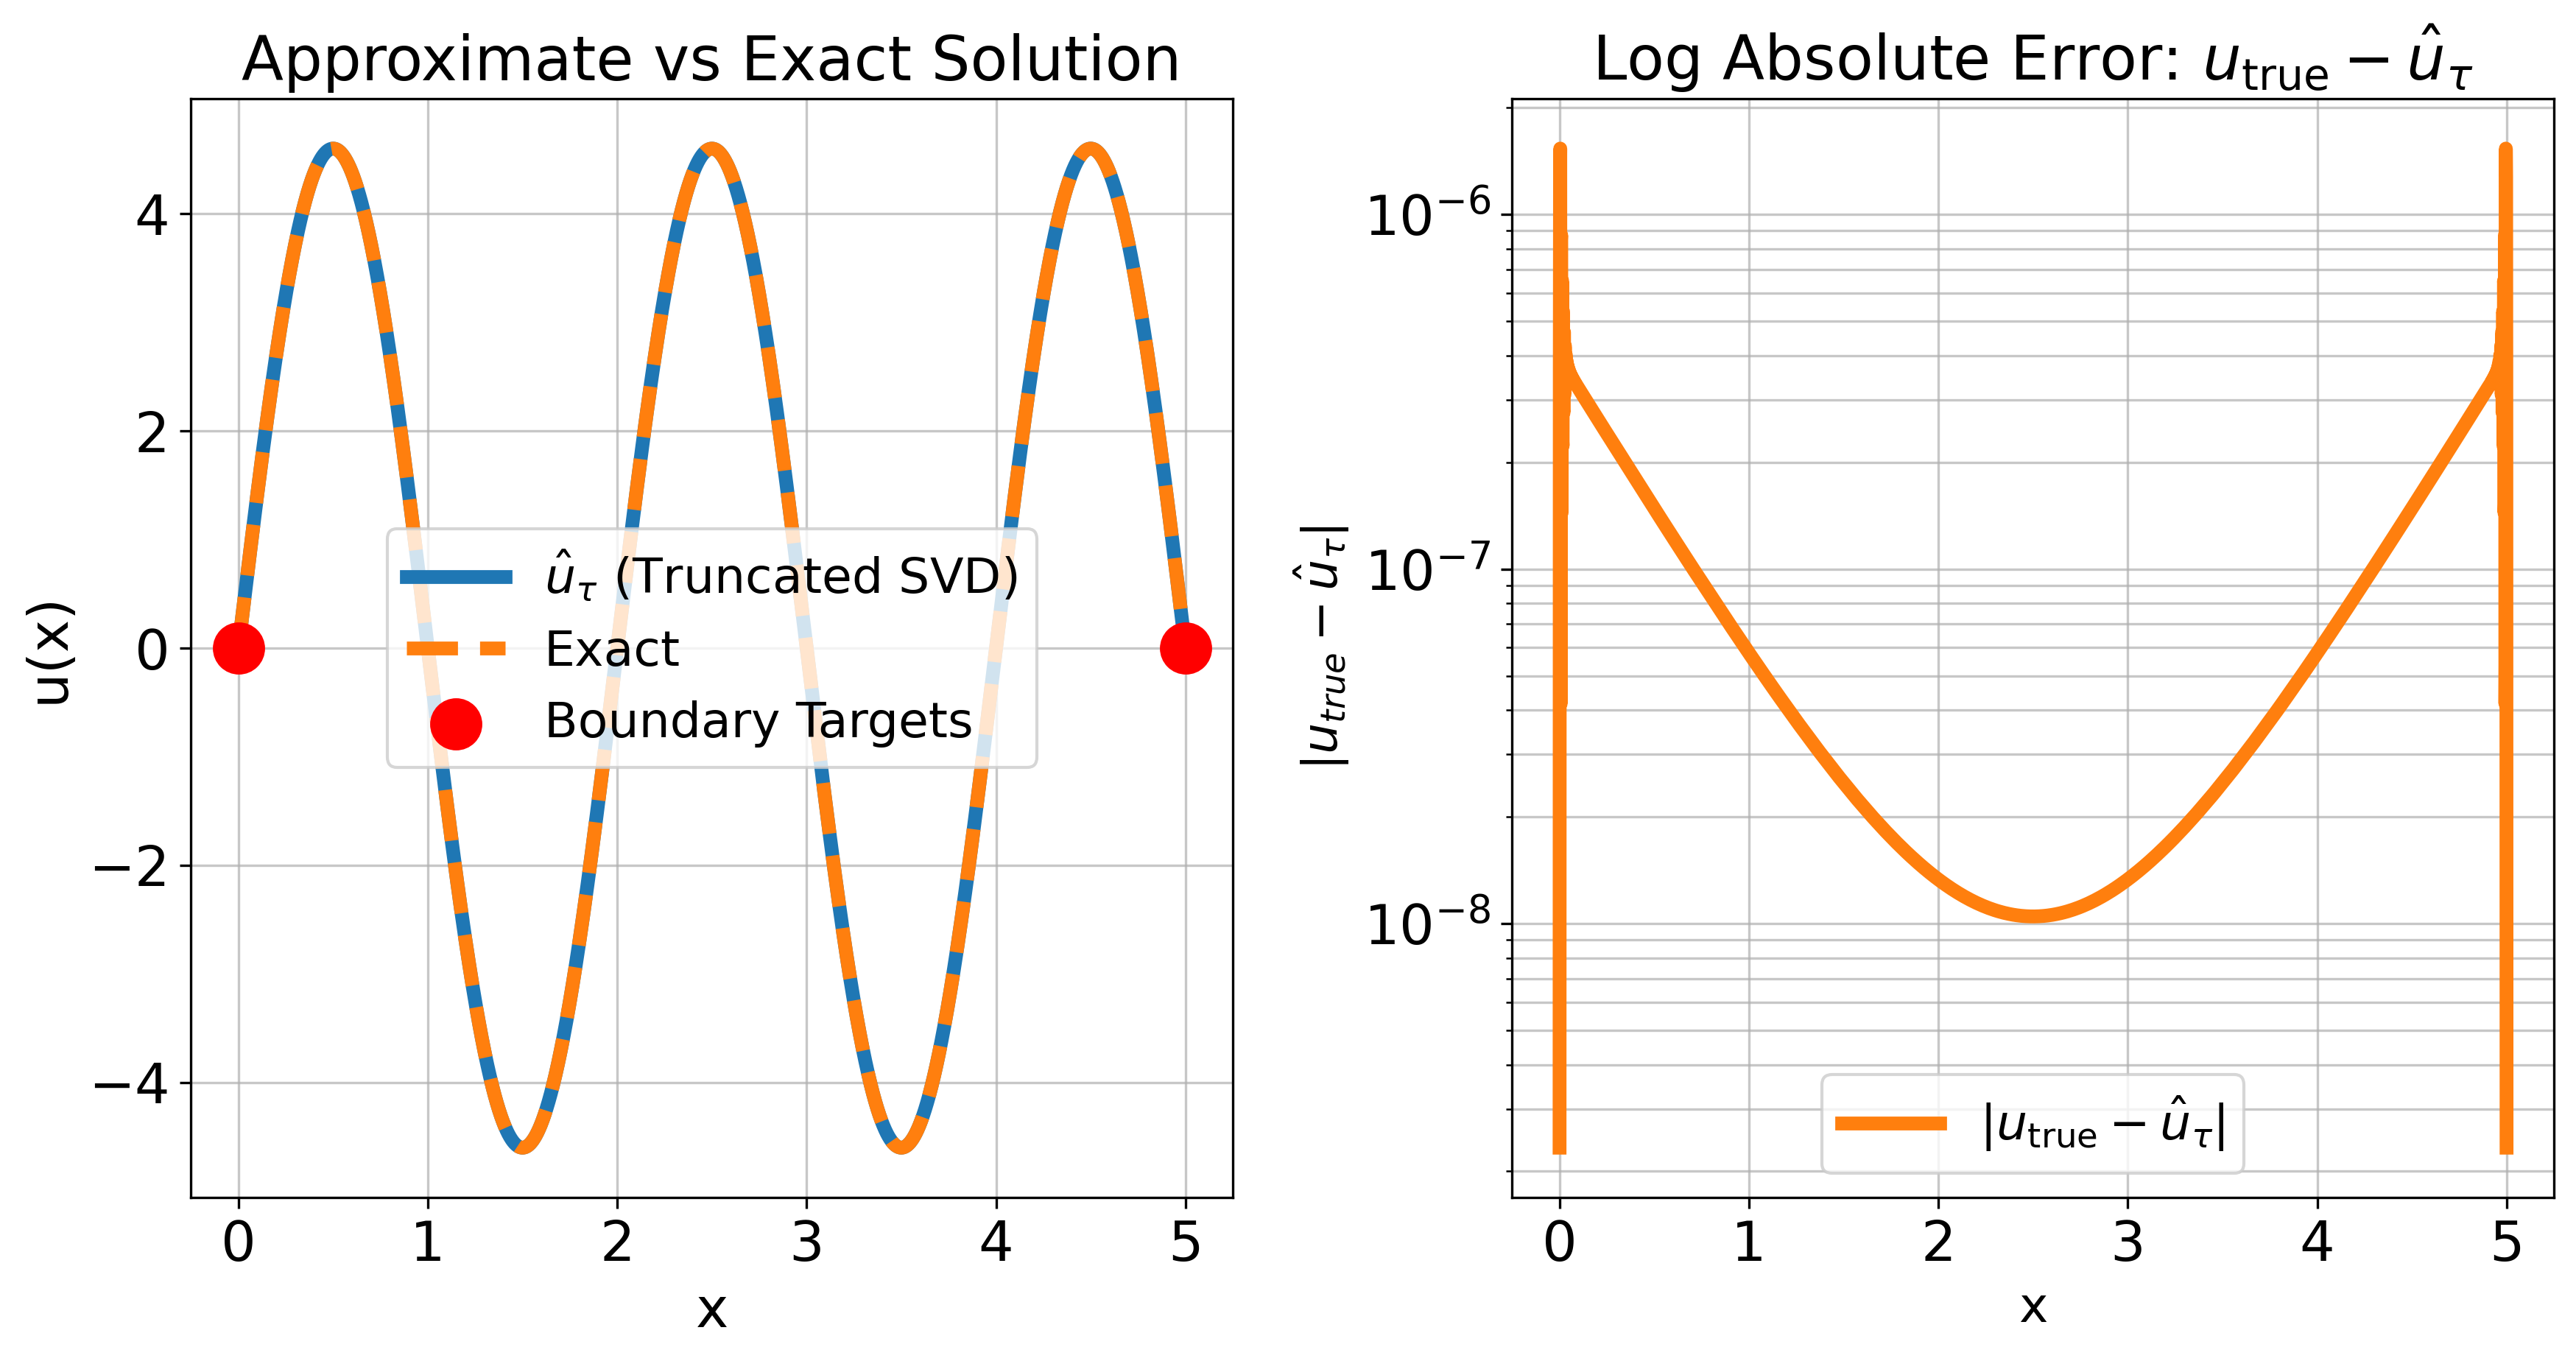

In [2]:
"""
Variational Gaussian-RBF solver for 1-D Helmholtz-type BVP
   -u'' + u = A * sin(pi x),  u(0)=u(L)=0
using a truncated SVD (TSVD) pseudo-inverse,
with interior quadrature points (x_int) and boundary points (x_bdry).

Author: Phuong Dong 
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.linalg import svd, lstsq
from numpy import pi

# ---------------------------------------------------------------------
# 1) Problem & numerical parameters
# ---------------------------------------------------------------------
L         = 5.0        # domain length
Amplitude = 50.0       # forcing amplitude
N         = 2000       # number of RBF centres
T         = 1.0        # expansion factor for centers
zeta      = 2          # oversampling factor for interior quadrature points
beta      = 3e5        # Dirichlet penalty weight
tau       = 1e-15      # TSVD relative cutoff (keep s_i > tau * s_max)

# ---- shape parameter (kept as-is, no rescaling) ---------------------
c   =  0.134
eps = c * N
print(f"eps = {eps:.3g}")

# ---------------------------------------------------------------------
# 2) Gaussian RBF and derivative w.r.t. x
# ---------------------------------------------------------------------
def gaussian_rbf(r, eps):
    return np.exp(-(eps * r) ** 2)

def d_gaussian_rbf(r, eps):
    return -2.0 * eps**2 * r * np.exp(-(eps * r) ** 2)

def assemble_basis(x_eval, centers, eps, deriv=0):
    """
    Return Phi (deriv=0) or Phi_x (deriv=1).
    Shape: len(x_eval) × len(centers)
    """
    r = cdist(x_eval[:, None], centers[:, None])
    if deriv == 0:
        return gaussian_rbf(r, eps)
    elif deriv == 1:
        diff = x_eval[:, None] - centers[None, :]
        # derivative w.r.t x: chain rule with sign(diff)
        return d_gaussian_rbf(np.abs(diff), eps) * np.sign(diff)
    else:
        raise ValueError("deriv must be 0 or 1")

# ---------------------------------------------------------------------
# 3) Centres, interior quadrature, and boundary points
# ---------------------------------------------------------------------
a, b = 0.0, L
Lh = 0.5 * (b - a)
q  = 0.5 * (a + b)

# RBF centres on expanded interval [q - T L/2, q + T L/2]
centers = np.linspace(q - T * Lh, q + T * Lh, N)

# Interior quadrature points (includes endpoints for trapezoid weights)
M_int = max(4, int(zeta * N))
x_int = np.linspace(a, b, M_int)
x_bdry = np.array([a, b])

# Trapezoid weights on [a,b]
w = np.ones(M_int)
w[0] = w[-1] = 0.5
dx = (b - a) / (M_int - 1)
W = (w * dx)[:, None]     # column vector for weighted products

# Basis matrices
Phi_int   = assemble_basis(x_int, centers, eps, deriv=0)
Phi_x_int = assemble_basis(x_int, centers, eps, deriv=1)

# Boundary penalty rows
P0 = gaussian_rbf(np.abs(centers - a), eps)  # at x=a
PL = gaussian_rbf(np.abs(centers - b), eps)  # at x=b
P  = np.vstack([P0, PL])                     # 2 × N

# ---------------------------------------------------------------------
# 4) Forcing and exact solution (for f(x)=A sin(pi x))
# ---------------------------------------------------------------------
def u_true(A, x):
    # Particular solution that satisfies Dirichlet BCs automatically
    # (-u''+u)(sin(pi x)/(1+pi^2)) = sin(pi x)
    return A * np.sin(pi * x) / (1.0 + pi**2)

f_int = Amplitude * np.sin(pi * x_int)

# ---------------------------------------------------------------------
# 5) Assemble A w = b  (weak form)
# ---------------------------------------------------------------------
# Weighted integrals for stiffness/mass and RHS
A_core = Phi_x_int.T @ (W * Phi_x_int) + Phi_int.T @ (W * Phi_int)
b_core = Phi_int.T @ (W.flatten() * f_int)

# Dirichlet penalty (homogeneous BC -> no RHS addition)
A_pen = beta * (P.T @ P)

A = A_core + A_pen
b_vec = b_core.copy()

# ---------------------------------------------------------------------
# 6) Solve with TSVD (and LSQ for diagnostics)
# ---------------------------------------------------------------------
U, s, Vt = svd(A, full_matrices=False)
smax = s[0]
mask = s > tau * smax
k = int(mask.sum())
#print(f"TSVD keeps {k}/{len(s)} singular values (tau={tau:g})")

sinv = np.zeros_like(s)
sinv[mask] = 1.0 / s[mask]
A_tsvd_inv = (Vt.T * sinv) @ U.T
w_tsvd = A_tsvd_inv @ b_vec

# (optional) plain least-squares
w_star, *_ = lstsq(A, b_vec, rcond=None)

# ---------------------------------------------------------------------
# 7) Evaluate solution, compute relative L2 error
# ---------------------------------------------------------------------
x_plot = np.linspace(a, b, M_int)
Phi_plot = assemble_basis(x_plot, centers, eps, deriv=0)

u_num = Phi_plot @ w_tsvd
u_ex  = u_true(Amplitude, x_plot)
g_bdry = u_true(Amplitude, x_bdry) 

# Continuous L2 via trapezoid
num = np.trapz((u_num - u_ex)**2, x_plot)
den = np.trapz(u_ex**2, x_plot)




rel_L2 = num / den
print(f"Relative L2 error (TSVD): {rel_L2:.3e}")
print(f"u_tau(0)={u_num[0]:.4e}, u_tau(L)={u_num[-1]:.4e} (Dirichlet: 0)")

# ---------------------------------------------------------------------
# 8) Plot
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})

fig, ax = plt.subplots(1, 2, figsize=(12, 6.5))


# Font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16
linewidth = 4.5


# (a) Numerical vs exact


# ── top-left: numerical vs reference
ax[0].plot(x_plot, u_num, label=r'$\hat{u}_{\tau}$ (Truncated SVD)', linewidth=linewidth)
ax[0].plot(x_plot, u_ex, '--', label='Exact', linewidth=linewidth)
ax[0].scatter(x_bdry, g_bdry, color='red', label='Boundary Targets', zorder=5)
ax[0].set(title='Approximate vs Exact Solution')
ax[0].set_xlabel('x', fontsize=label_fontsize)
ax[0].set_ylabel('u(x)', fontsize=label_fontsize)
ax[0].tick_params(labelsize=tick_fontsize)
ax[0].legend(loc = 'center',fontsize=legend_fontsize)
ax[0].grid(True)


# (b) Squared absolute error (log)
ax[1].semilogy(x_plot, np.abs(u_num - u_ex)**2,
               label=r'$|u_{\text{true}}-\hat{u}_\tau|$', color = 'tab:orange' )
ax[1].set_xlabel('x'); ax[1].set_ylabel(r'$|u_{\text{true}}-\hat{u}_\tau|$')
ax[1].set(title=r'Log Absolute Error: $u_{\mathrm{true}} - \hat{u}_{\tau}$', xlabel='x', ylabel=r'$|u_{true} - \hat{u}_{\tau}|$')
ax[1].grid(True,which='both')
ax[1].tick_params(labelsize=tick_fontsize)
ax[1].legend(fontsize=legend_fontsize)


plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig1_reactiondiffusion.png', dpi = 300)
